# D03 · Reliability is about differences between people

A task can reliably activate the same region at the group level yet poorly distinguish individuals across visits. The group question asks whether an average response differs from zero. An individual-differences question asks whether stable variation between people can be separated from measurement and occasion noise. These are related but not interchangeable targets. A strong group effect does not establish that a person's rank is stable enough to predict their behavior.

In an elementary measurement model, each observed value is a stable person value plus independent error. The theoretical reliability ratio is between-person variance divided by total variance. This ratio can be small because measurement noise is large or because the population is unusually homogeneous. Reliability therefore belongs to a population, measurement procedure, and repeat interval. It is not an unchanging property stamped on a task's name.

The first simulation generates two visits for 1,000 people, with between-person variance one and measurement-error variance four. Their expected correlation is 1/(1+4), or 0.2. A second version averages 16 independent trials at each visit. Under this specific model, averaging divides the error variance by 16 and raises the theoretical reliability to 0.8. Real trial errors may be correlated, participants may fatigue, and repeated trials may change the process being measured; the gain need not follow this formula.

We also distinguish consistency from absolute agreement. Add ten units to everybody at visit two. Pearson correlation does not change because ordering and linear association are preserved, yet visits now disagree systematically. A suitable intraclass correlation coefficient depends on whether raters/visits are fixed or random and whether consistency or agreement is the target; we do not label a Pearson coefficient an ICC. Inspect a difference plot and state the measurement target before choosing a reliability statistic. This is particularly important when AI reports a single impressive number without naming its definition.

Predict reliability for one versus 16 independent trials. Simulated correlations fluctuate around their theoretical targets.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(203)
n = 1000
person = rng.normal(size=n)
visit1 = person + rng.normal(0, 2, n)
visit2 = person + rng.normal(0, 2, n)
avg1 = person + rng.normal(0, 2 / np.sqrt(16), n)
avg2 = person + rng.normal(0, 2 / np.sqrt(16), n)
r_single = np.corrcoef(visit1, visit2)[0, 1]
r_average = np.corrcoef(avg1, avg2)[0, 1]
assert np.isclose(1 / (1 + 4), 0.2)
assert np.isclose(1 / (1 + 4 / 16), 0.8)
assert r_average > r_single + 0.4
print('Observed repeat correlations:', r_single, r_average)

Observed repeat correlations: 0.202229273564665 0.81471979181993


Introduce a systematic visit shift. One summary misses it; another catches it.

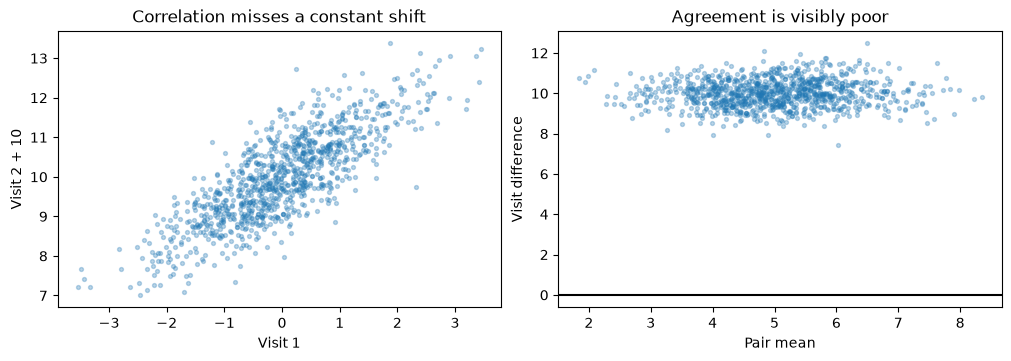

In [2]:
shifted = avg2 + 10
assert np.isclose(np.corrcoef(avg1, shifted)[0, 1], r_average)
assert np.isclose((shifted - avg1).mean() - (avg2 - avg1).mean(), 10)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
ax[0].scatter(avg1, shifted, s=8, alpha=.3)
ax[0].set(xlabel='Visit 1', ylabel='Visit 2 + 10', title='Correlation misses a constant shift')
ax[1].scatter((avg1 + shifted) / 2, shifted - avg1, s=8, alpha=.3)
ax[1].axhline(0, color='black')
ax[1].set(xlabel='Pair mean', ylabel='Visit difference', title='Agreement is visibly poor')
plt.show()

## Supervise the AI, then transfer the idea

**AI prompt:** “Explain why a group-average activation is insufficient evidence of individual reliability. Derive the two variance ratios without calling correlation an ICC. Ask me whether a constant visit shift should alter correlation. Then produce a paired difference plot in at most 15 lines.”

**Deliberate mistake:** report the unchanged correlation after adding ten units as proof of unchanged accuracy. Repair the report by separating consistency, agreement, and validity. A stable artifact can itself be highly reliable; reliability is necessary for some uses but does not prove biological validity. Transfer to a real project by asking about repeated scans, scan interval, preprocessing consistency, the intended ICC model, uncertainty, and whether reliability was measured in the target population. Deliver a table with two intended uses—group contrast and individual prediction—and the distinct evidence each requires.

## Answer key — read after your own explanation

The toy theoretical ratios are 0.2 and 0.8; the fixed-seed sample should show a much larger repeated-measure correlation after trial averaging. A constant visit shift preserves correlation but worsens absolute agreement. The trial-averaging formula assumes independent errors with stable signal. Increasing between-person heterogeneity can raise reliability without improving the scanner. A reliable measure can still measure the wrong construct.

## Source trail

Original explanations and synthetic experiments; these are parallel learning materials, not an official USC syllabus. [Elliott et al., task-fMRI test–retest meta-analysis and empirical study](https://pmc.ncbi.nlm.nih.gov/articles/PMC7370246/); [DartBrains Group Analysis](https://github.com/ljchang/dartbrains/blob/b72537ad25deee0281248a415a052cd87ff325de/content/Group_Analysis.ipynb) provides the course connection to within/between-person variation. This reliability lab extends that course topic rather than claiming an upstream dedicated reliability lesson. See [the coverage and gaps](../../curriculum/design_coverage.md).